    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [54]:
inds_30 = pd.read_csv('csv/30_industry.csv')
inds_30['Date'] = pd.to_datetime(inds_30['Date'])
inds_30 = inds_30.set_index('Date')
inds_30.info()
inds_30

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Food    6539 non-null   float64
 1   Beer    6539 non-null   float64
 2   Smoke   6539 non-null   float64
 3   Games   6539 non-null   float64
 4   Books   6539 non-null   float64
 5   Hshld   6539 non-null   float64
 6   Clths   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Chems   6539 non-null   float64
 9   Txtls   6539 non-null   float64
 10  Cnstr   6539 non-null   float64
 11  Steel   6539 non-null   float64
 12  FabPr   6539 non-null   float64
 13  ElcEq   6539 non-null   float64
 14  Autos   6539 non-null   float64
 15  Carry   6539 non-null   float64
 16  Mines   6539 non-null   float64
 17  Coal    6539 non-null   float64
 18  Oil     6539 non-null   float64
 19  Util    6539 non-null   float64
 20  Telcm   6539 non-null   float64
 21  Servs   6539 non-nu

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-2.27,-1.16,1.67,-1.57,-2.49,-2.75,-2.40,-0.58,-1.76,-3.74,...,-1.26,2.47,2.24,-2.35,-0.97,-0.62,-2.57,-2.12,-4.11,-2.06
2000-01-04,-2.27,-1.11,0.64,-0.07,-2.72,-2.10,-3.62,-4.39,-1.74,-3.23,...,-4.40,-4.93,-5.68,-2.26,-2.58,-2.96,-3.46,-1.82,-3.90,-1.36
2000-01-05,0.10,1.33,-0.41,-0.40,-2.20,-1.42,1.96,2.32,3.39,1.37,...,0.01,-1.25,-0.90,2.16,0.27,2.16,-0.97,1.19,-0.47,0.21
2000-01-06,1.16,1.29,-1.28,-1.63,0.23,2.69,-0.45,2.68,4.31,-0.26,...,-1.92,-4.03,-5.41,3.17,3.00,3.39,-0.13,-0.73,3.23,0.26
2000-01-07,1.23,5.25,2.75,0.84,-1.23,5.40,1.08,7.61,1.59,1.67,...,0.93,3.46,3.56,1.70,1.10,2.85,4.79,1.50,2.01,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.46,0.21,0.37,0.16,0.28,0.72,1.71,0.58,0.46,0.83,...,0.64,0.19,0.18,0.29,0.30,0.27,0.52,0.63,0.53,0.23
2025-12-26,-0.08,-0.10,-0.21,0.68,-0.71,0.11,0.79,-0.05,0.36,0.37,...,-0.18,-0.15,0.33,0.47,-0.19,0.14,0.19,-0.24,-0.13,-0.56
2025-12-29,0.18,0.19,0.41,-0.44,-0.26,-0.16,0.00,-0.26,-0.37,-0.25,...,0.43,-0.35,-0.44,0.19,-0.30,-0.25,-0.16,-0.59,-0.71,0.44


In [65]:
# ── 고정 파라미터 ──
gamma = 0.0    # regularization 제거
x_min = 0.0
x_max = 1.0   # box constraint 제거

N_STOCKS = len(inds_30.columns)

HORIZON    = 21
N          = HORIZON
M          = N_STOCKS   # 10
C          = 1.0
d          = 1.0
lam        = 0.7
delta      = 20          # risk aversion
HIDDEN_DIM = 128
EPOCHS     = 100
BATCH_SIZE = 16
LR         = 1e-4
PATIENCE   = 20

# ── 실험 grid ──
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.3, 0.4, 0.5]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]


In [56]:
inds_30 = inds_30.sort_index()
inds_30 = inds_30[~inds_30.index.duplicated(keep='first')]
inds_30 = inds_30 / 100.0

stock_names = inds_30.columns.tolist()

# =============================================================================
# 2. Train / Val / Test 분리 (날짜 기준)
# =============================================================================
TRAIN_START = "2000-01-01"
TRAIN_END   = "2012-12-31"   # Train : 13년
VAL_START   = "2013-01-01"
VAL_END     = "2017-12-31"   # Val   :  5년
BT_START    = "2018-01-01"
BT_END      = "2025-12-31"   # Test  :  8년

train_df = inds_30[TRAIN_START : TRAIN_END]
is_df    = inds_30[TRAIN_START : VAL_END]
val_df   = inds_30[VAL_START   : VAL_END]
bt_df    = inds_30[BT_START    : BT_END]

train_np = train_df.values
val_np   = val_df.values
bt_np    = bt_df.values

N_TRAIN = len(train_df)
N_VAL   = len(val_df)
N_BT    = len(bt_df)
N_DAYS  = len(inds_30)

print(f"전체  : {inds_30.index[0].date()} → {inds_30.index[-1].date()}  ({N_DAYS} days)")
print(f"Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({N_TRAIN} days)")
print(f"Val   : {val_df.index[0].date()} → {val_df.index[-1].date()}  ({N_VAL} days)")
print(f"BT    : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목  : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
# Train 기간 통계로 표준화 (변수명 is_mean/is_std 유지 — .py 파일 호환)
is_mean = train_np.mean(axis=0)   # shape (10,)
is_std  = train_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (lookback, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # Train 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

full_np       = np.vstack([train_np, val_np, bt_np])
VAL_START_IDX = N_TRAIN
BT_START_IDX  = N_TRAIN + N_VAL

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]
    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    print(f"\n[LOOKBACK={LOOKBACK}, n1={n1}]")
    print(f"  Train 학습 샘플 수  : {len(train_samples)}")
    print(f"  Val 전체 샘플 수    : {len(val_samples)}")
    print(f"  BT 리밸런싱 횟수    : {len(rebal_samples)}")

전체  : 2000-01-03 → 2025-12-31  (6539 days)
Train : 2000-01-03 → 2012-12-31  (3269 days)
Val   : 2013-01-02 → 2017-12-29  (1259 days)
BT    : 2018-01-02 → 2025-12-31  (2011 days)
종목  : ['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth', 'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other']

[LOOKBACK=252, n1=0.3]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.4]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=252, n1=0.5]
  Train 학습 샘플 수  : 2997
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.3]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.4]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    : 95

[LOOKBACK=504, n1=0.5]
  Train 학습 샘플 수  : 2745
  Val 전체 샘플 수    : 1239
  BT 리밸런싱 횟수    :

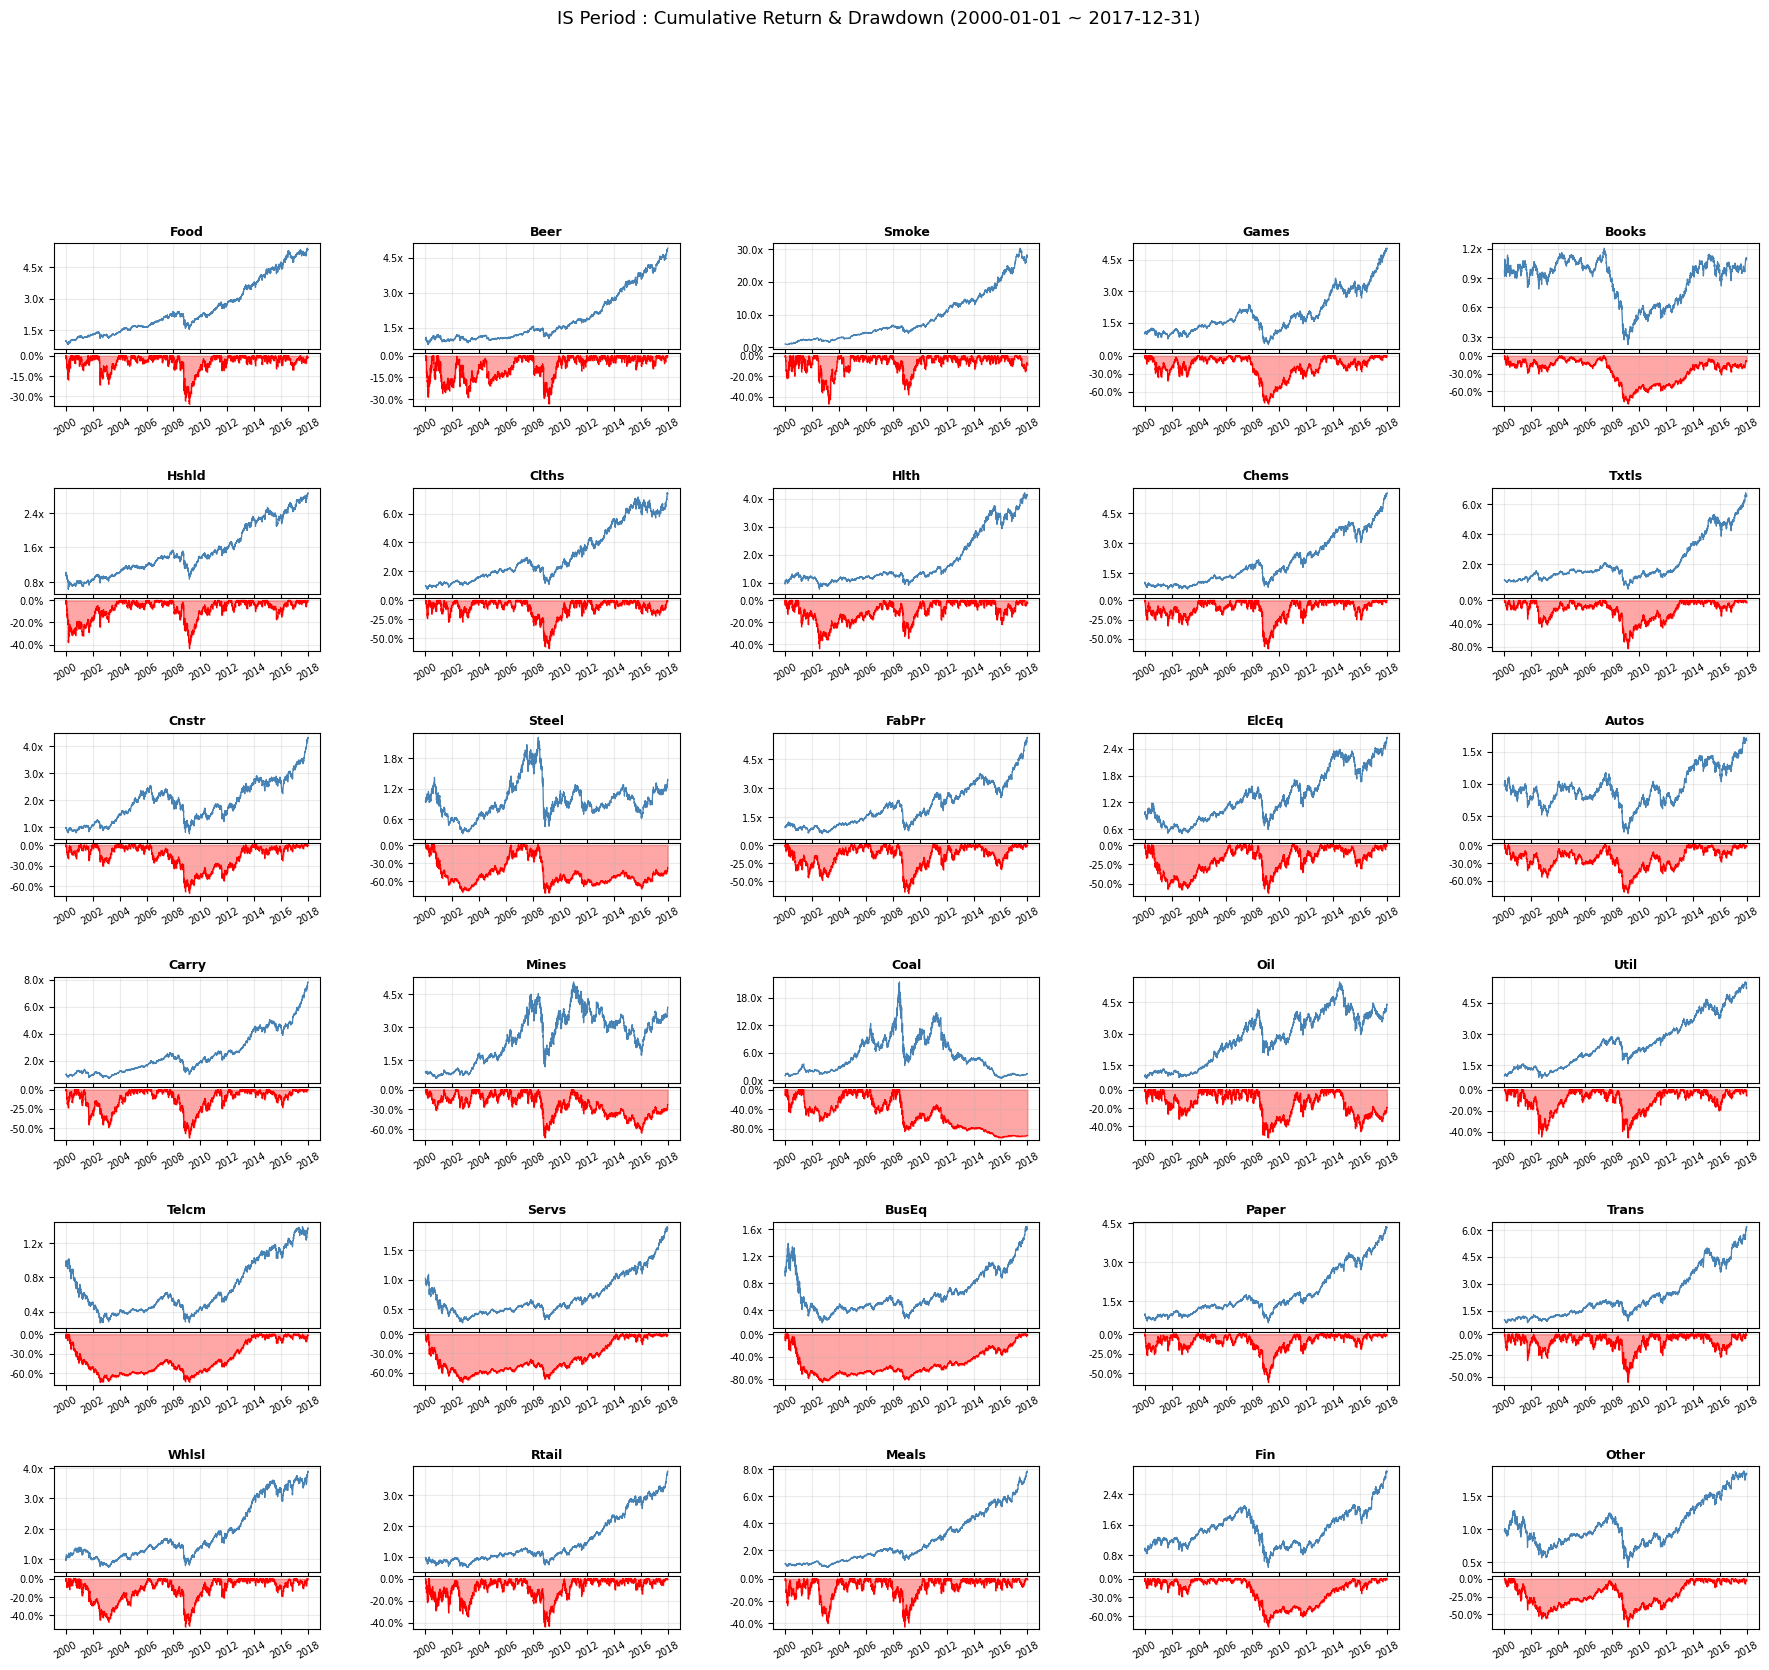

In [57]:
from matplotlib.ticker import MaxNLocator

is_cum = (1 + is_df).cumprod()
is_dd  = (is_cum - is_cum.cummax()) / is_cum.cummax()

cols   = is_cum.columns.tolist()
N_COLS = 5
N_ROWS = len(cols) // N_COLS        # 30 // 5 = 6

fig = plt.figure(figsize=(22, 18))   # ← 6행 × 5 = 30인치
outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.5, wspace=0.35)

for i, col in enumerate(cols):
    row, c = divmod(i, N_COLS)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, c],
        hspace=0.05, height_ratios=[2, 1]
    )

    ax_ret = fig.add_subplot(inner[0])
    ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

    # 상단: 누적 수익률
    ax_ret.plot(is_cum.index, is_cum[col], color="steelblue", linewidth=0.9)
    ax_ret.set_title(col, fontsize=9, fontweight="bold")
    ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
    ax_ret.yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))  # ← tick 4개 강제
    ax_ret.tick_params(axis="x", labelbottom=False)
    ax_ret.tick_params(labelsize=7)
    ax_ret.grid(True, alpha=0.25)

    # 하단: Drawdown
    ax_dd.fill_between(is_dd.index, is_dd[col], 0, alpha=0.35, color="red")
    ax_dd.plot(is_dd.index, is_dd[col], color="red", linewidth=0.8)
    ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))  # ← 소수점 1자리
    ax_dd.yaxis.set_major_locator(MaxNLocator(nbins=3, prune="both"))   # ← tick 3개 강제
    ax_dd.tick_params(labelsize=7)
    ax_dd.tick_params(axis="x", rotation=30)
    ax_dd.grid(True, alpha=0.25)

fig.suptitle(f"IS Period : Cumulative Return & Drawdown ({TRAIN_START} ~ {VAL_END})",
             fontsize=13, y=1.01)
plt.show()


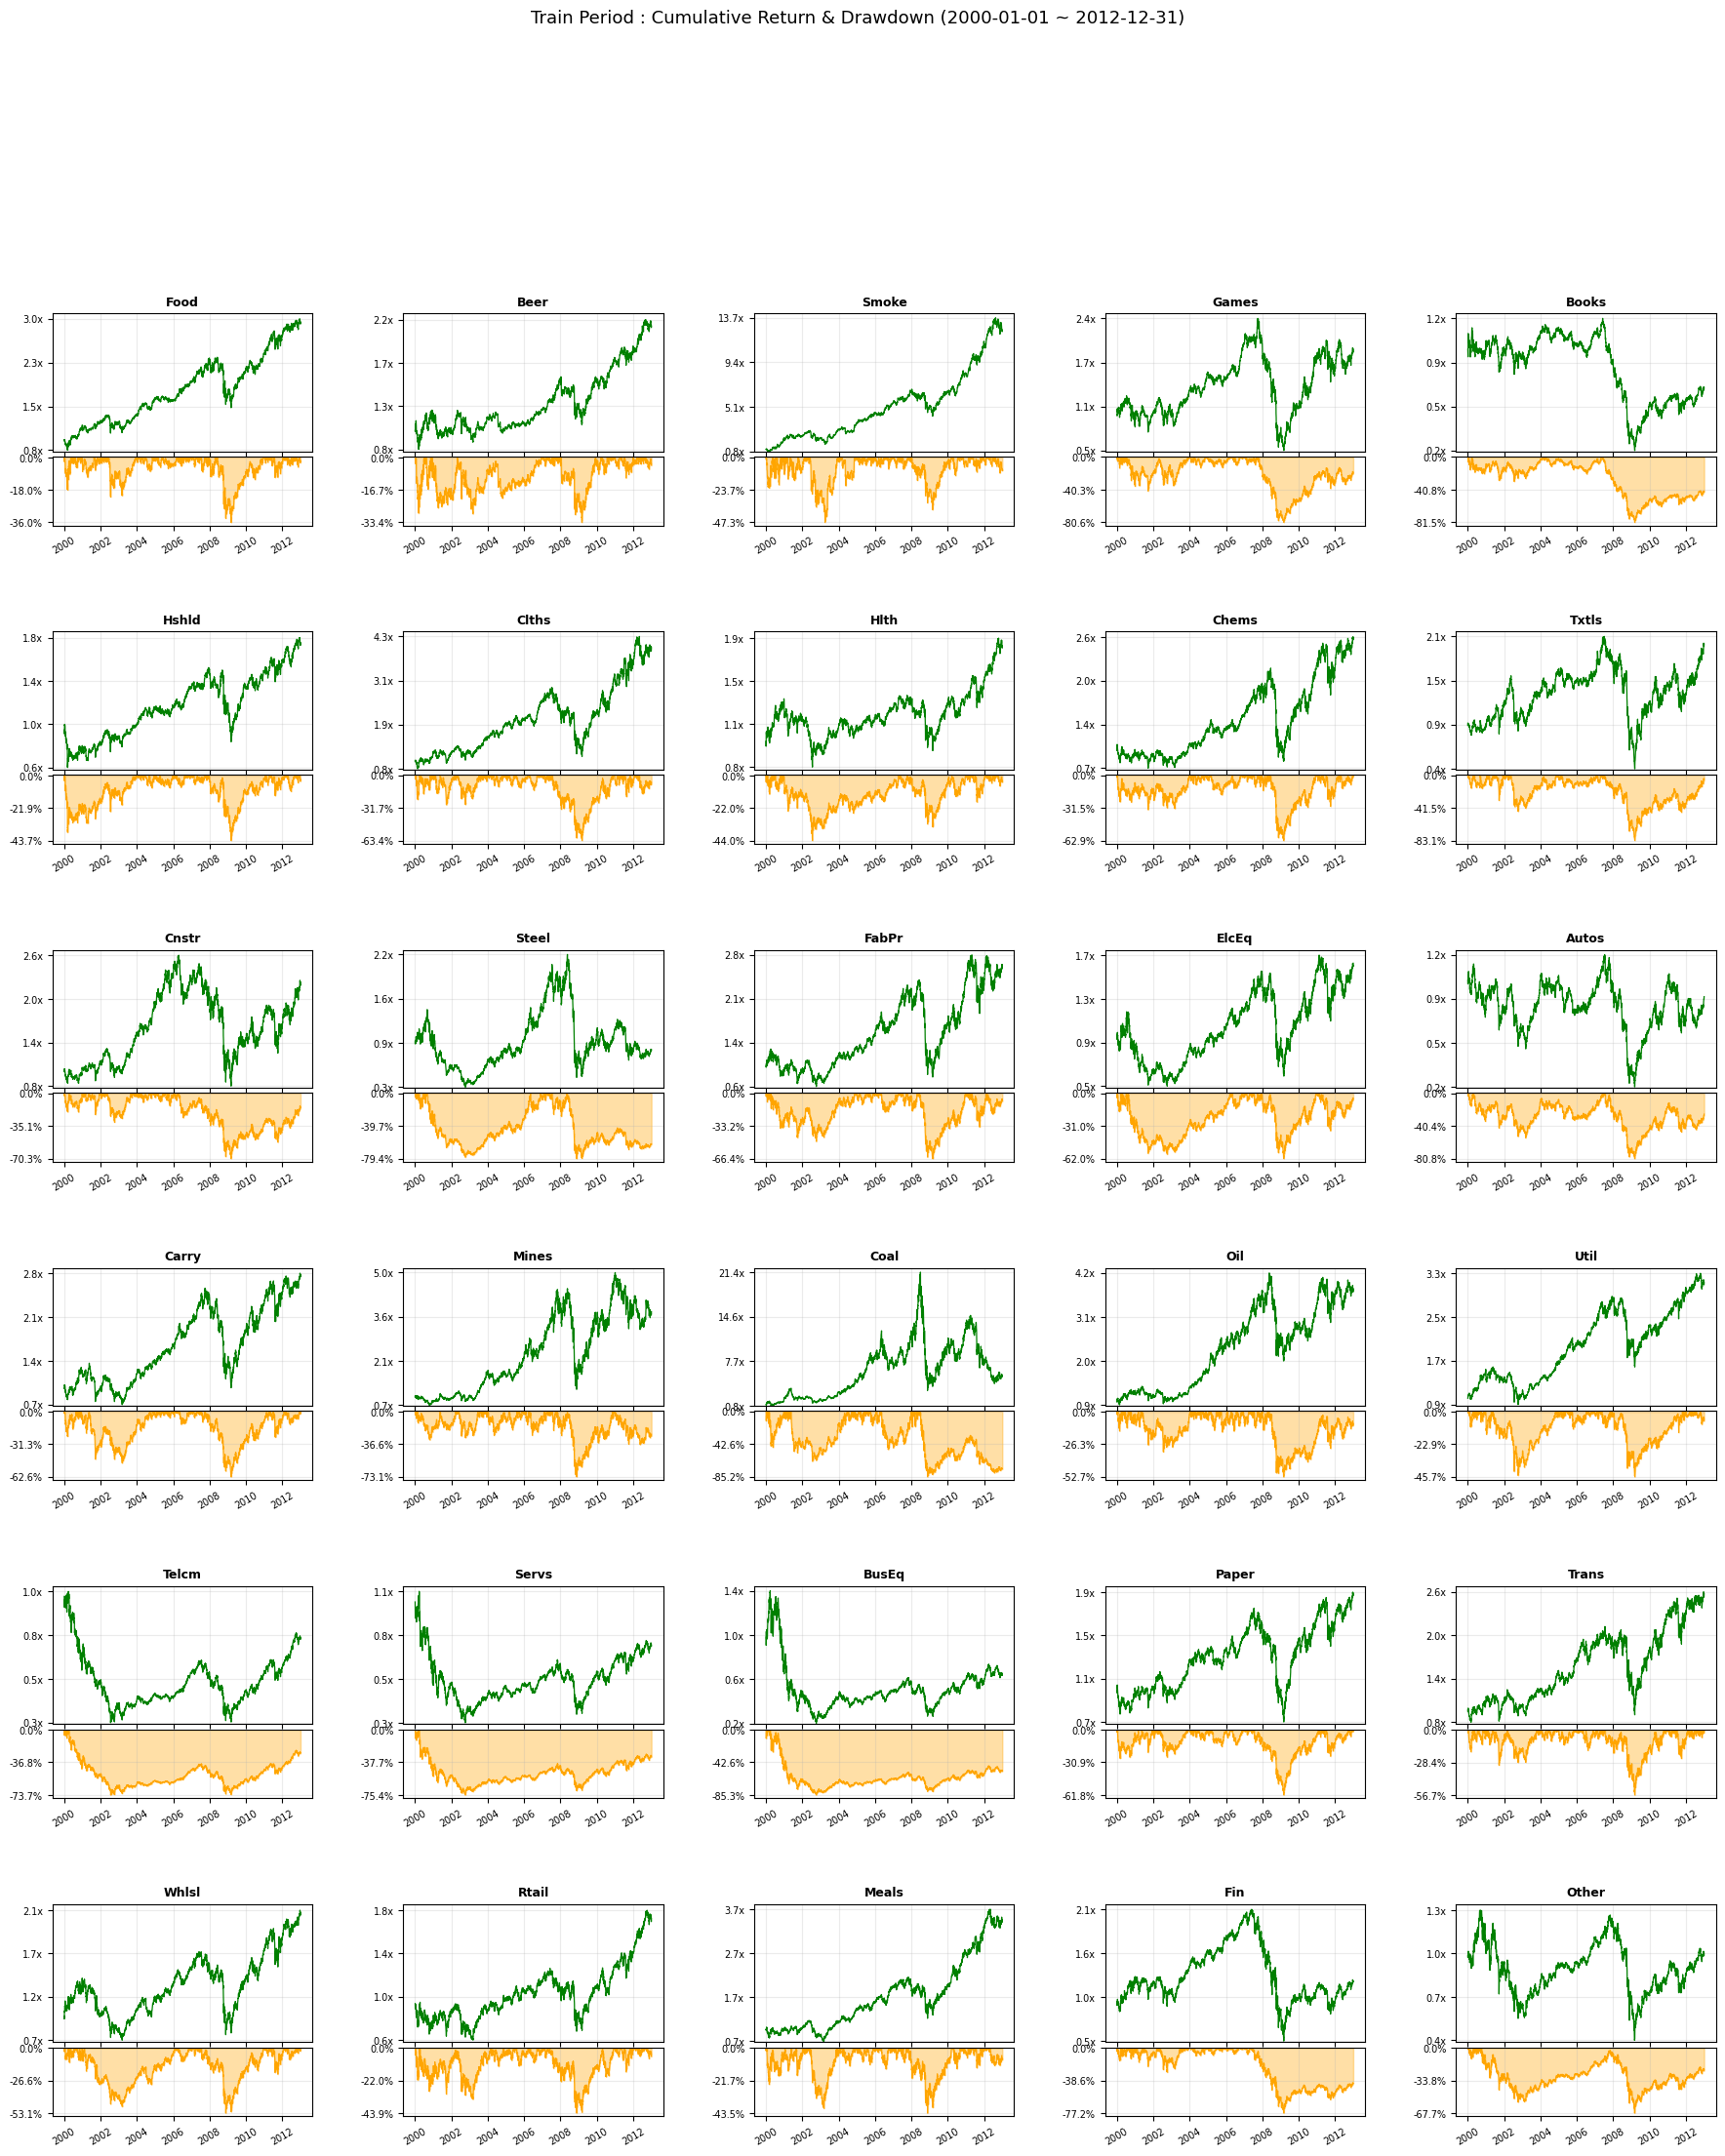

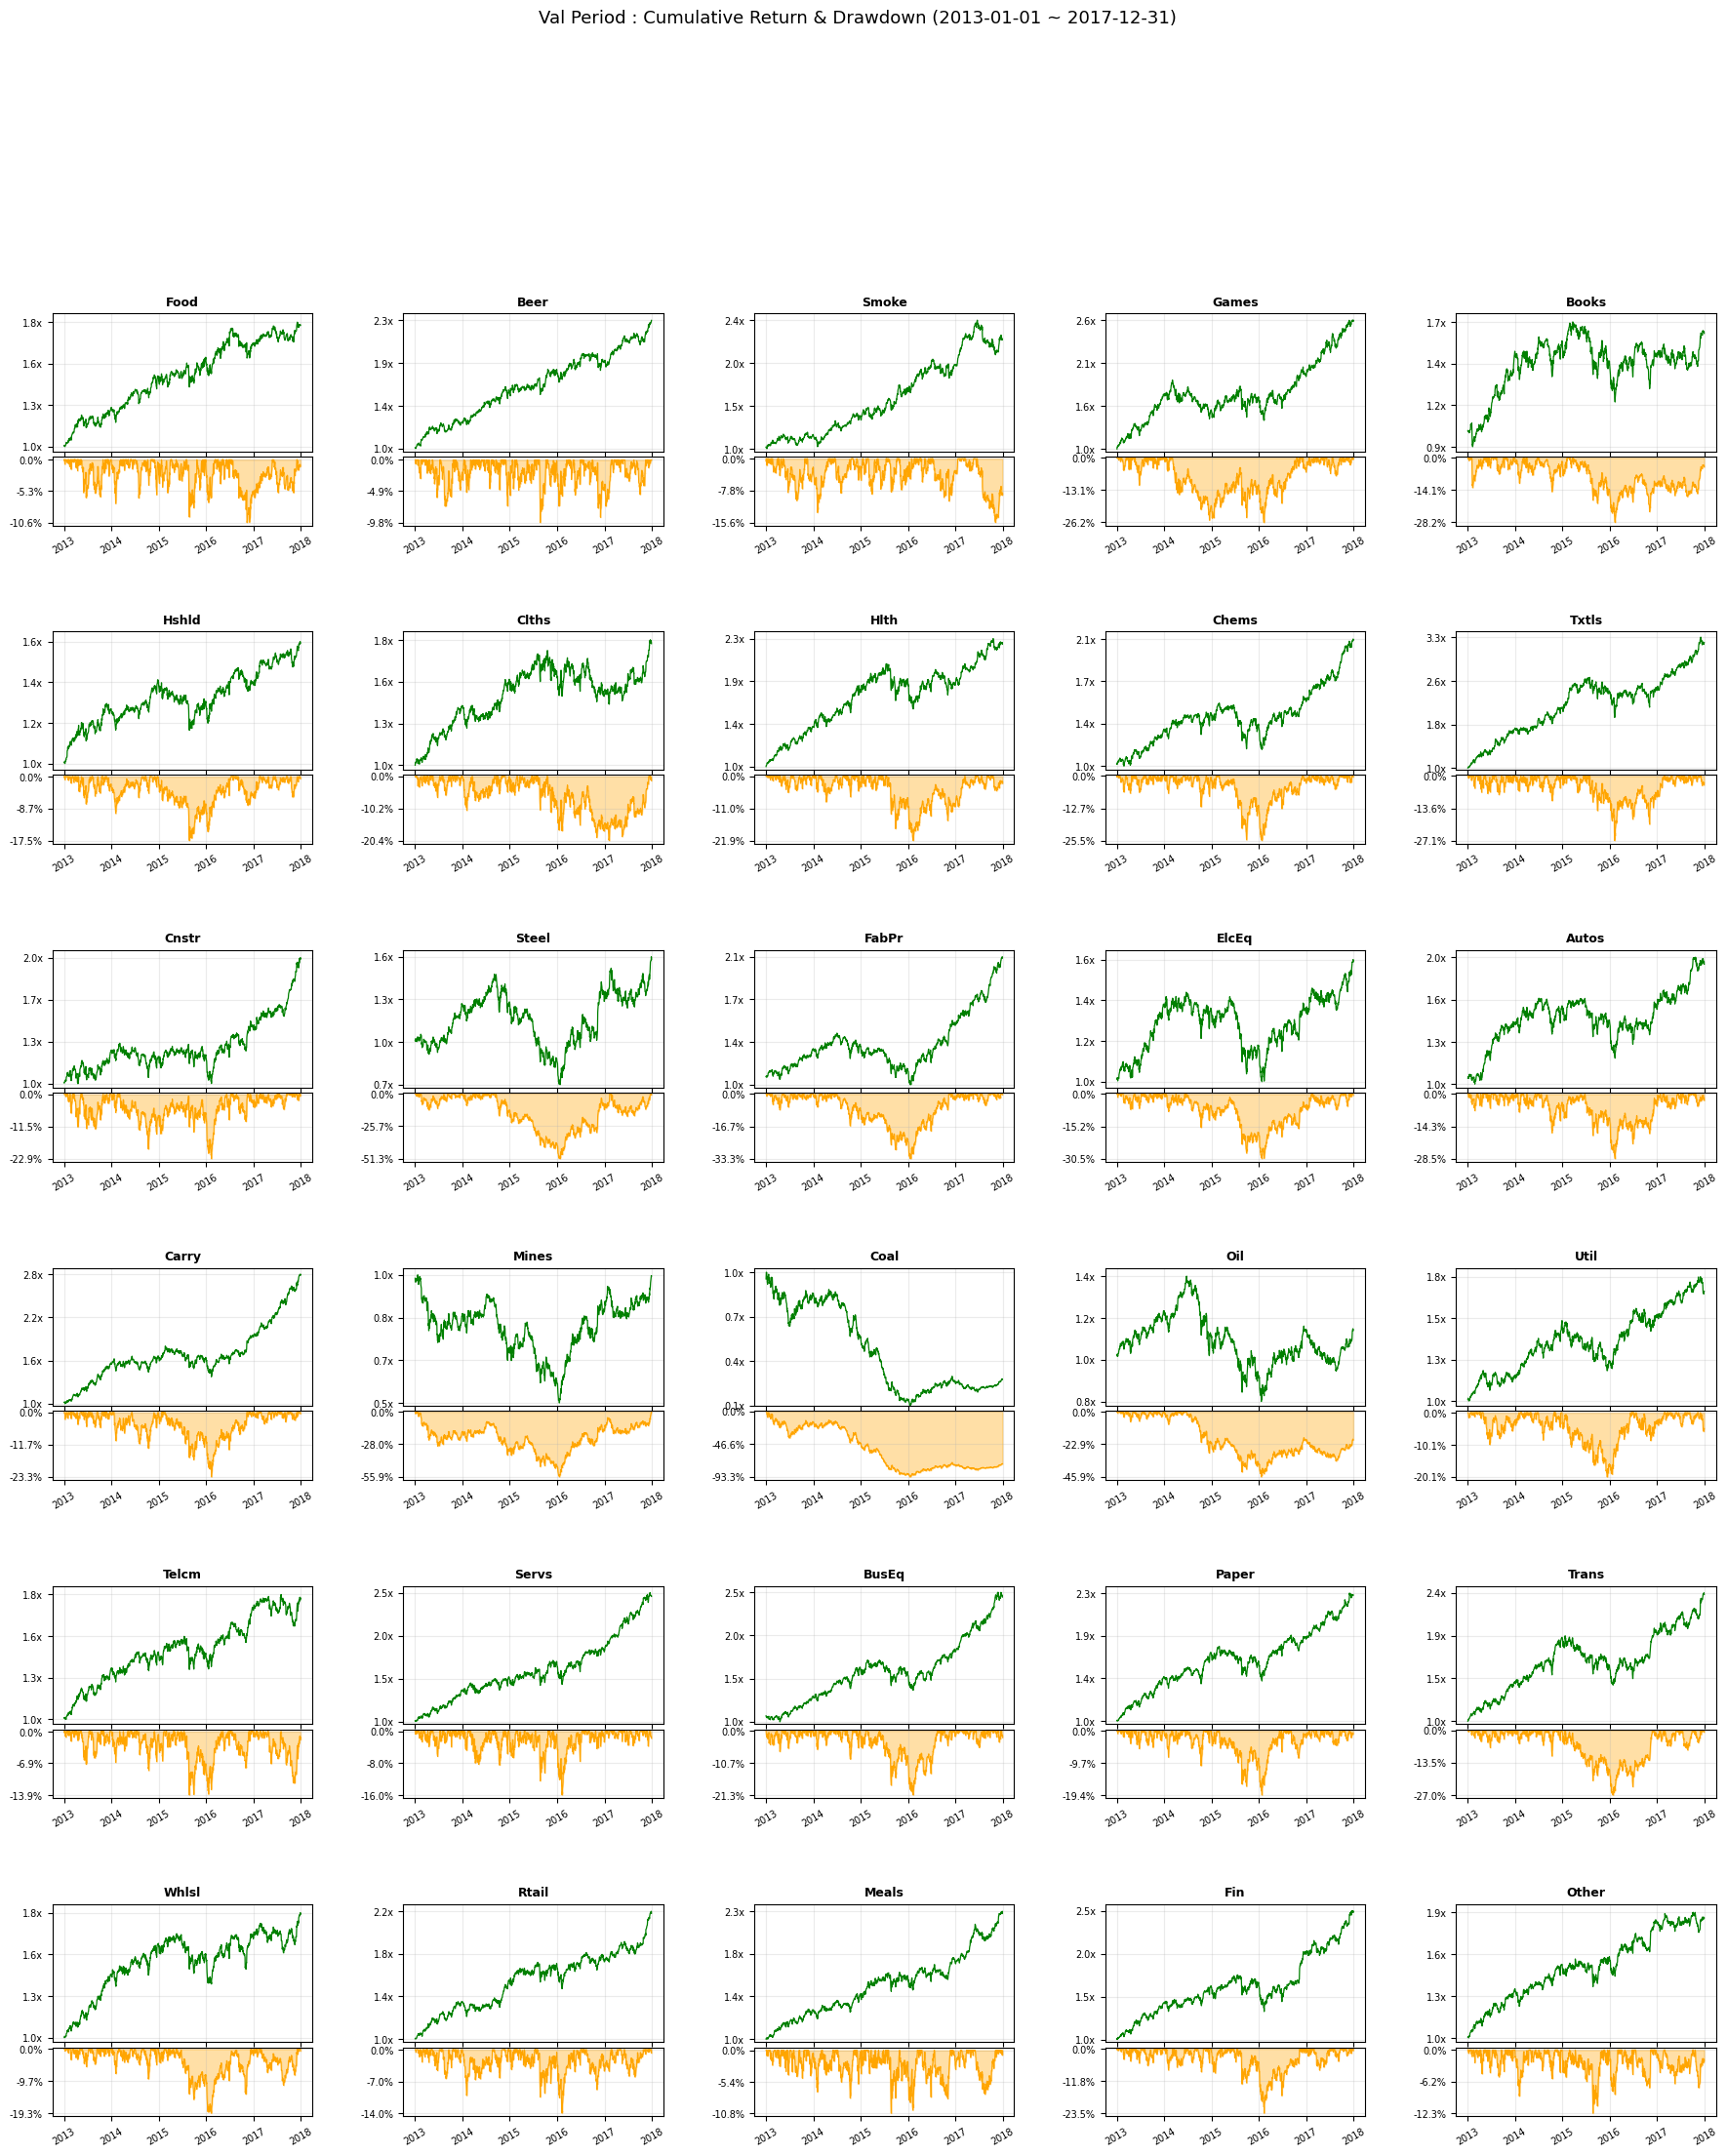

In [58]:
from matplotlib.ticker import FixedLocator, FixedFormatter

for period_df, period_name, p_start, p_end in [
    (train_df, "Train", TRAIN_START, TRAIN_END),
    (val_df,   "Val",   VAL_START,   VAL_END),
]:
    cum  = (1 + period_df).cumprod()
    dd   = (cum - cum.cummax()) / cum.cummax()
    cols = cum.columns.tolist()

    N_COLS = 5
    N_ROWS = len(cols) // N_COLS

    fig = plt.figure(figsize=(22, 24))
    outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.5, wspace=0.35)

    for i, col in enumerate(cols):
        row, c = divmod(i, N_COLS)
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[row, c],
            hspace=0.05, height_ratios=[2, 1]
        )

        ax_ret = fig.add_subplot(inner[0])
        ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

        # 상단: 누적 수익률
        ax_ret.plot(cum.index, cum[col], color="green", linewidth=0.9)
        ax_ret.set_title(col, fontsize=9, fontweight="bold")

        y_min, y_max = cum[col].min(), cum[col].max()
        ax_ret.set_ylim(y_min * 0.97, y_max * 1.03)          # 축 범위 고정
        ret_ticks = np.linspace(y_min, y_max, 4)
        ax_ret.yaxis.set_major_locator(FixedLocator(ret_ticks))
        ax_ret.yaxis.set_major_formatter(FixedFormatter([f"{v:.1f}x" for v in ret_ticks]))
        ax_ret.tick_params(axis="x", labelbottom=False, labelsize=7)
        ax_ret.tick_params(axis="y", labelsize=7)
        ax_ret.grid(True, alpha=0.25)

        # 하단: Drawdown
        ax_dd.fill_between(dd.index, dd[col], 0, alpha=0.35, color="orange")
        ax_dd.plot(dd.index, dd[col], color="orange", linewidth=0.8)

        d_min = dd[col].min()
        ax_dd.set_ylim(d_min * 1.05, 0.005)                  # 축 범위 고정
        dd_ticks = np.linspace(d_min, 0, 3)
        ax_dd.yaxis.set_major_locator(FixedLocator(dd_ticks))
        ax_dd.yaxis.set_major_formatter(FixedFormatter([f"{v*100:.1f}%" for v in dd_ticks]))
        ax_dd.tick_params(axis="x", rotation=30, labelsize=7)
        ax_dd.tick_params(axis="y", labelsize=7)
        ax_dd.grid(True, alpha=0.25)

    fig.suptitle(f"{period_name} Period : Cumulative Return & Drawdown ({p_start} ~ {p_end})",
                 fontsize=13, y=1.01)
    plt.show()


In [59]:
def plot_multi_pnl(results_list, figsize=(14, 8)):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"height_ratios": [3, 1]},
                                   sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    for (bt_results, label), color in zip(results_list, colors):
        pv = [1.0]
        for res in bt_results:
            w    = res["w_real"]
            base = pv[-1]
            pv.extend((base * (1 + w)).tolist())

        pv          = np.array(pv)
        running_max = np.maximum.accumulate(pv)
        drawdown    = (running_max - pv) / (running_max + 1e-10)
        total_ret   = pv[-1] - 1.0
        max_dd      = drawdown.max()
        calmar      = total_ret / (max_dd + 1e-10)

        full_label = f"{label}  R:{total_ret:.1%}  MDD:{max_dd:.1%}  Cal:{calmar:.2f}"
        ax1.plot(np.arange(len(pv)), pv, color=color, linewidth=1.5, label=full_label)
        ax2.plot(np.arange(len(pv)), -drawdown * 100, color=color, linewidth=1.0, alpha=0.7)

    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title("Cumulative PnL Comparison")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.25)

    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()




  Config: LOOKBACK=252, n1=0.3

── DFL-MDD Training (with Val Early Stopping) ──
  Epoch   1/100  train=-0.001332  val=-0.025853  *
  Epoch   5/100  train=0.004034  val=-0.025913  (2/20)
  Epoch  10/100  train=0.004699  val=-0.020932  (7/20)
  Epoch  15/100  train=0.004042  val=-0.021140  (12/20)
  Epoch  20/100  train=0.004326  val=-0.020587  (17/20)
  Early stopping at epoch 23  (best val=-0.027624)

── Backtest : DFL-MDD ──
 Win    R_real    Sharpe    MDD(%)  Top-3 weights
---------------------------------------------------------------------------


Backtesting:  42%|████▏     | 40/95 [00:00<00:00, 394.69it/s]

    1    0.0385    0.1422   3.0436%  {'FabPr': 1.0, 'Hshld': 0.0, 'Cnstr': 0.0}
    2   -0.0583   -0.2157  10.5820%  {'FabPr': 1.0, 'Cnstr': 0.0, 'Whlsl': 0.0}
    3   -0.0020   -0.0069   8.2369%  {'FabPr': 1.0, 'Cnstr': 0.0, 'Autos': 0.0}
    4   -0.0730   -0.2873   8.5438%  {'Hshld': 1.0, 'FabPr': 0.0, 'Smoke': 0.0}
    5    0.0499    0.1584   3.2919%  {'FabPr': 1.0, 'Hshld': 0.0, 'Rtail': 0.0}
    6   -0.0667   -0.2109   8.6207%  {'FabPr': 1.0, 'Smoke': 0.0, 'Telcm': -0.0}
    7    0.0211    0.0800   1.1936%  {'Hshld': 1.0, 'FabPr': 0.0, 'Smoke': 0.0}
    8    0.0020    0.0062   4.1781%  {'FabPr': 1.0, 'Hshld': 0.0, 'Trans': 0.0}
    9    0.0117    0.0438   2.7189%  {'Hshld': 1.0, 'FabPr': 0.0, 'Smoke': 0.0}
   10   -0.1591   -0.4921  20.1258%  {'FabPr': 1.0, 'Cnstr': 0.0, 'Autos': 0.0}
   11    0.0620    0.1810   5.3866%  {'FabPr': 1.0, 'Telcm': 0.0, 'Rtail': 0.0}
   12   -0.0708   -0.2008  18.7848%  {'FabPr': 1.0, 'Hshld': 0.0, 'Smoke': 0.0}
   13    0.1034    0.2750   3.9164%  {'

Backtesting:  86%|████████▋ | 82/95 [00:00<00:00, 408.13it/s]

   81    0.1054    0.3087   1.2015%  {'FabPr': 1.0, 'Hshld': 0.0, 'Smoke': 0.0}
   82   -0.0457   -0.1325   6.6170%  {'FabPr': 1.0, 'Hshld': 0.0, 'Smoke': 0.0}


...

    1    0.0026    0.0094   2.5129%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Carry': 0.0}
    2   -0.0507   -0.1838   6.7086%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Meals': 0.0}
    3   -0.0242   -0.0855  10.1920%  {'Smoke': 1.0, 'Autos': 0.0, 'Food': 0.0}
    4   -0.1652   -0.5717  18.8648%  {'Smoke': 1.0, 'Meals': 0.0, 'Hlth': 0.0}
    5   -0.0110   -0.0355   3.2763%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Books': 0.0}
    6    0.0301    0.0968   2.0700%  {'Smoke': 1.0, 'Carry': 0.0, 'Meals': 0.0}
    7    0.0538    0.1723   2.5476%  {'Smoke': 1.0, 'Txtls': 0.0, 'Chems': 0.0}
    8    0.0014    0.0061   2.9917%  {'Smoke': 0.522, 'Whlsl': 0.478, 'Food': 0.0}
    9    0.0508    0.1603   2.8904%  {'Smoke': 1.0, 'Food': 0.0, 'Meals': 0.0}
   10    0.0962    0.3025   3.8207%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Books': 0.0}
   11   -0.0945   -0.2958  12.9075%  {'Smoke': 1.0, 'Carry': 0.0, 'Food': 0.0}
   12   -0.1768   -0.5527  20.4022%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Util': 0.0}
   13    0.0854    0.3024   1.3366%  {'Whl

Backtesting:  80%|████████  | 76/95 [00:00<00:00, 377.32it/s]

   74    0.0047    0.0144   2.3683%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Coal': -0.0}
   75    0.0265    0.0896   2.2915%  {'Whlsl': 0.891, 'Telcm': 0.109, 'Smoke': 0.0}
   76    0.0726    0.2293   2.7280%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Carry': 0.0}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 371.32it/s]


   77    0.0681    0.2150   1.7398%  {'Smoke': 1.0, 'Util': 0.0, 'Carry': 0.0}
   78    0.0021    0.0068   2.5669%  {'Smoke': 1.0, 'Util': 0.0, 'Telcm': 0.0}
   79    0.0978    0.3273   3.1192%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Coal': 0.0}
   80    0.0932    0.3124   0.9244%  {'Smoke': 1.0, 'Books': 0.0, 'Hshld': 0.0}
   81   -0.0444   -0.1489   5.9923%  {'Smoke': 1.0, 'Meals': 0.0, 'Util': 0.0}
   82    0.0884    0.3041   1.7707%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Books': -0.0}
   83    0.0182    0.0614   4.7148%  {'Smoke': 1.0, 'Meals': 0.0, 'Books': 0.0}
   84   -0.0775   -0.3502   8.4101%  {'Whlsl': 0.688, 'Smoke': 0.312, 'Hlth': 0.0}
   85    0.1348    0.4522   3.0073%  {'Smoke': 1.0, 'Carry': 0.0, 'Meals': 0.0}
   86    0.0593    0.1937   3.0687%  {'Smoke': 1.0, 'Whlsl': 0.0, 'Coal': 0.0}
   87   -0.0098   -0.0318   6.4790%  {'Smoke': 1.0, 'Coal': 0.0, 'Autos': 0.0}
   88    0.1271    0.4051   1.4256%  {'Smoke': 1.0, 'Food': 0.0, 'Hlth': 0.0}
   89    0.0301    0.1011   3.6429%  {'Smoke

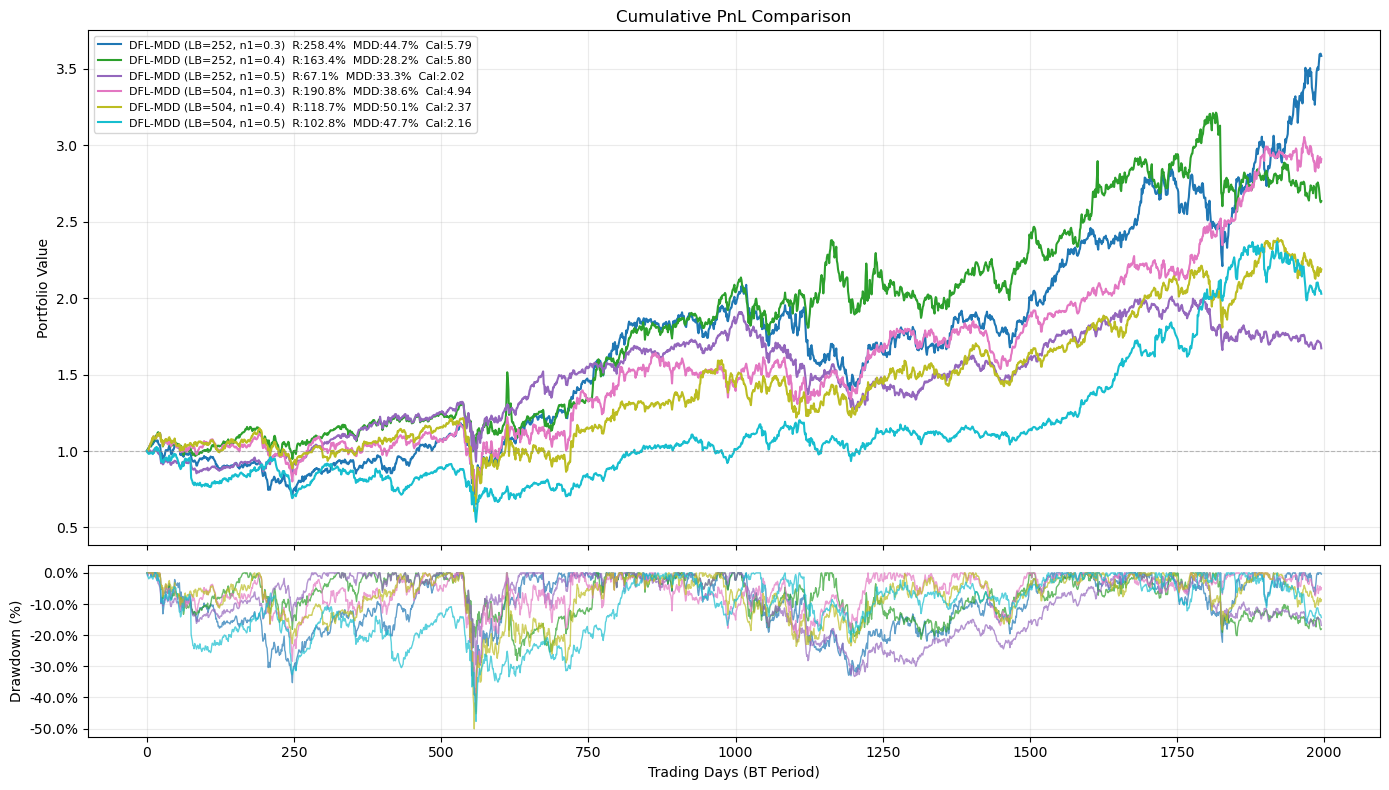

In [66]:
import importlib
import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass,
    train_dfl_mdd, backtest_dfl_mdd, plot_pnl,
)

all_results_dfl_mdd = []

for cfg in configs:
    LOOKBACK = cfg["LOOKBACK"]
    n1       = cfg["n1"]

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
    print(f"{'='*60}")

    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    val_samples   = val_samples[::HORIZON]    # 리밸런싱 간격으로 서브샘플 (속도)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    opt_layer  = build_optimization_layer(N, M, gamma, delta=delta)

    train_dfl_mdd(
        pred_model, opt_layer, train_samples, val_samples,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
        n1=n1, C=C, d=d, x_min=x_min, x_max=x_max, lam=lam,
        is_mean=is_mean, is_std=is_std, delta=delta,
        patience=PATIENCE,
    )

    bt_dfl_mdd = backtest_dfl_mdd(
        pred_model=pred_model, opt_layer=opt_layer,
        rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
        n1=n1, x_min=x_min, x_max=x_max,
        delta=delta, is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_dfl_mdd.append((bt_dfl_mdd, f"DFL-MDD (LB={LOOKBACK}, n1={n1})"))

plot_multi_pnl(all_results_dfl_mdd)


  Config: LOOKBACK=252, n1=0.3

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/100  train=0.003949  val=0.001294  *
  Epoch   5/100  train=0.000333  val=0.000202  *
  Epoch  10/100  train=0.000300  val=0.000146  *
  Epoch  15/100  train=0.000300  val=0.000136  *
  Epoch  20/100  train=0.000302  val=0.000134  *
  Epoch  25/100  train=0.000301  val=0.000134  (1/20)
  Epoch  30/100  train=0.000301  val=0.000134  *
  Epoch  35/100  train=0.000301  val=0.000134  (2/20)
  Epoch  40/100  train=0.000300  val=0.000134  (7/20)
  Epoch  45/100  train=0.000302  val=0.000134  (12/20)
  Epoch  50/100  train=0.000301  val=0.000134  (17/20)
  Early stopping at epoch 53  (best val=0.000134)

── Backtest : PTO-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------
    1    0.0124   2.4200%  {'Smoke': 0.546, 'Mines': 0.247, 'Coal': 0.207}
    2   -0.0127   8.0051%  {'Smoke': 0.518, 'Mines': 0.248, 'Coal': 0.233}
    3   -0.0336   7

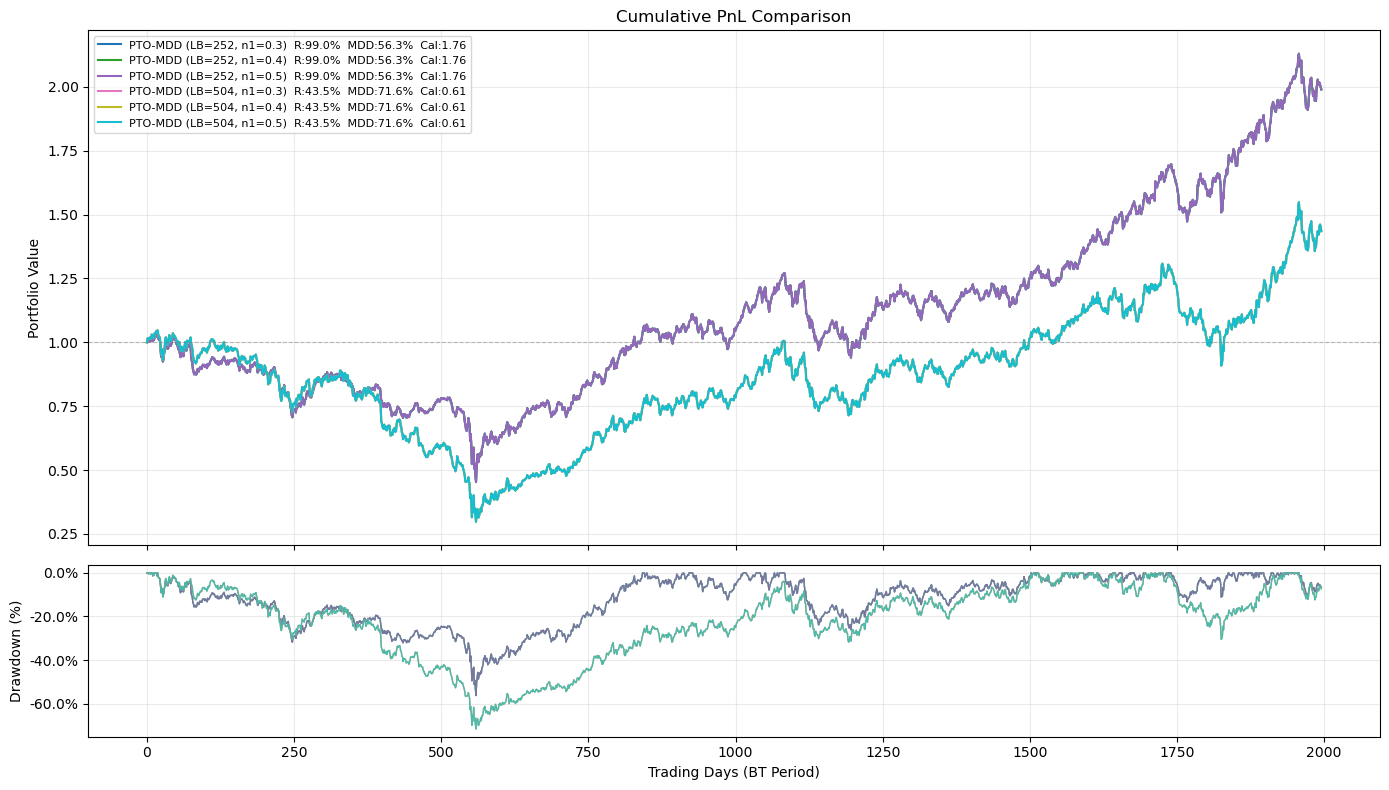

In [61]:
import importlib
import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd import train_pto_mdd, backtest_pto_mdd

all_results_pto_mdd = []

for cfg in configs:
    LOOKBACK = cfg["LOOKBACK"]
    n1       = cfg["n1"]

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
    print(f"{'='*60}")

    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    train_pto_mdd(model_pto_mdd, train_samples, val_samples,
                  EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

    bt_pto_mdd = backtest_pto_mdd(
        model_pto_mdd, rebal_samples, N, d, C,
        n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
        delta=delta,
        is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_pto_mdd.append((bt_pto_mdd, f"PTO-MDD (LB={LOOKBACK}, n1={n1})"))

plot_multi_pnl(all_results_pto_mdd)


  Config: LOOKBACK=252

── PTO-MVO Training (MSE + Val Early Stopping) ──
  Epoch   1/100  train=0.003949  val=0.001294  *
  Epoch   5/100  train=0.000333  val=0.000202  *
  Epoch  10/100  train=0.000300  val=0.000146  *
  Epoch  15/100  train=0.000300  val=0.000136  *
  Epoch  20/100  train=0.000302  val=0.000134  *
  Epoch  25/100  train=0.000301  val=0.000134  (1/20)
  Epoch  30/100  train=0.000301  val=0.000134  *
  Epoch  35/100  train=0.000301  val=0.000134  (2/20)
  Epoch  40/100  train=0.000300  val=0.000134  (7/20)
  Epoch  45/100  train=0.000302  val=0.000134  (12/20)
  Epoch  50/100  train=0.000301  val=0.000134  (17/20)
  Early stopping at epoch 53  (best val=0.000134)

── Backtest : PTO-MVO ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------
    1    0.0272   1.6121%  {'Smoke': 0.164, 'Meals': 0.093, 'Food': 0.084}
    2   -0.0507   7.4859%  {'Smoke': 0.152, 'Meals': 0.091, 'Food': 0.086}
    3   -0.0064   4.9601%  

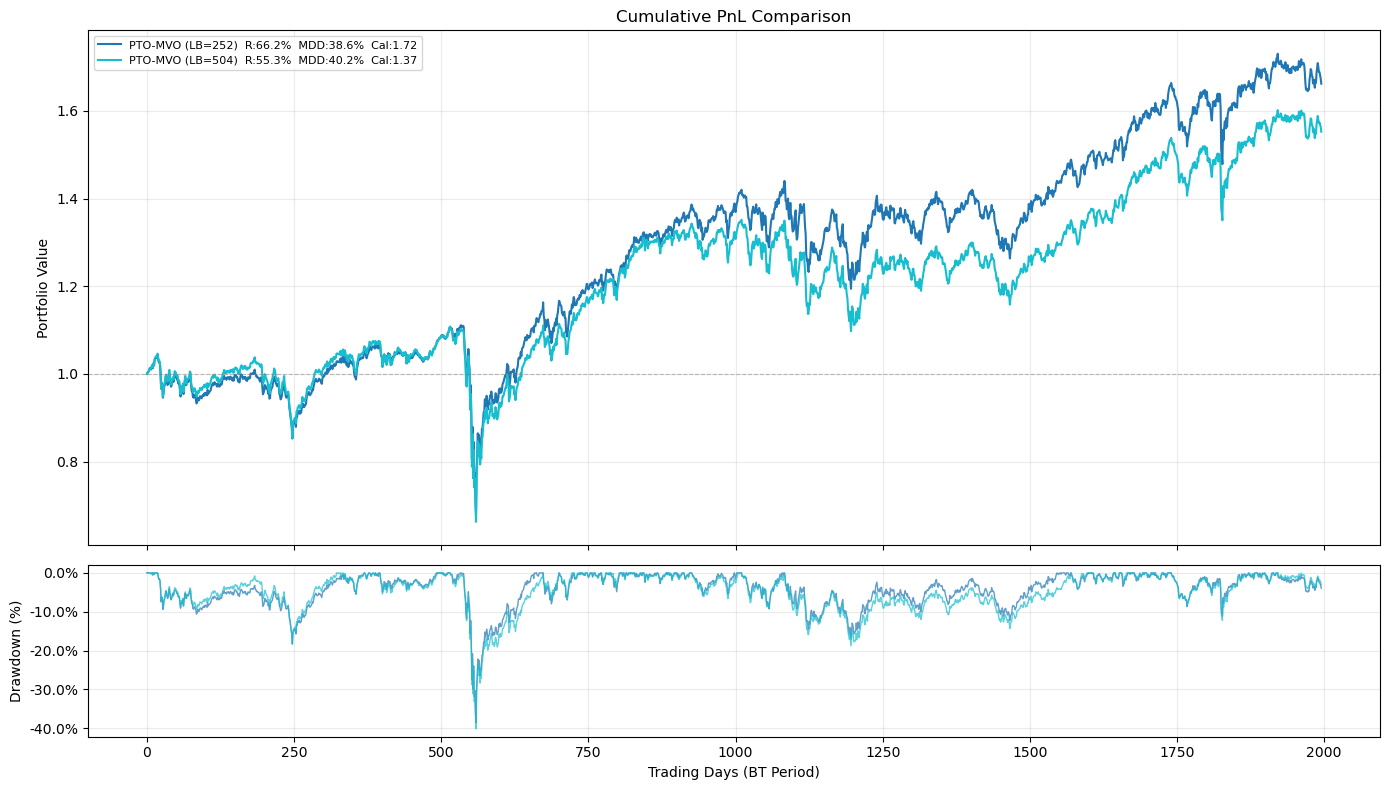

In [62]:
import importlib
import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo import train_pto_mvo, backtest_pto_mvo

all_results_mvo = []

for lookback in LOOKBACK_LIST:

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={lookback}")
    print(f"{'='*60}")

    INPUT_DIM = lookback * N_STOCKS

    train_samples = make_windows(full_np, lookback, HORIZON,
                                 start=lookback, end=N_TRAIN)
    val_samples   = make_windows(full_np, lookback, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, lookback, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    train_pto_mvo(model_pto_mvo, train_samples, val_samples,
                  EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

    bt_pto_mvo = backtest_pto_mvo(
        model_pto_mvo, rebal_samples, N, d, C,
        delta=delta,
        x_min=x_min, x_max=x_max, gamma=gamma,
        is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_mvo.append((bt_pto_mvo, f"PTO-MVO (LB={lookback})"))

plot_multi_pnl(all_results_mvo)